In [ ]:
from __future__ import annotations
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

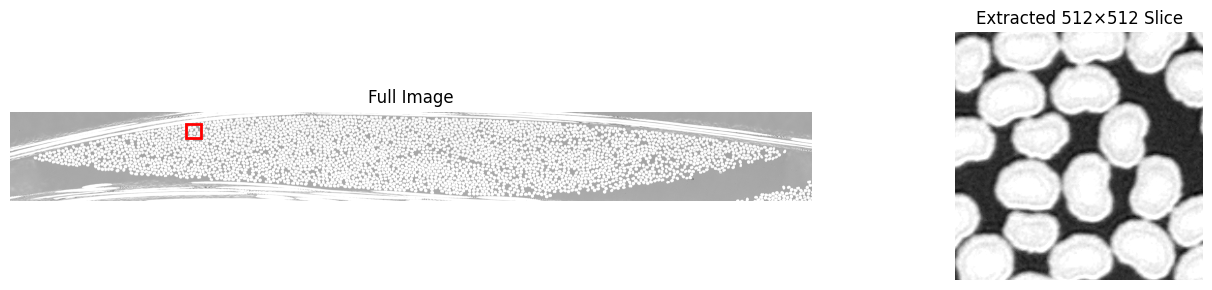

In [58]:
file_path = Path("../../data/promotion/245_004.tiff")

x0 = 3030
y0 = 200
w = 256
img_np = np.array(Image.open(file_path).convert("L"))

# Extract slice
sliced_img = img_np[y0:y0+w, x0:x0+w]

# --- Plot ---
fig, ax = plt.subplots(1, 2, figsize=(15, 3))

# ---- Left: full image with rectangle ----
ax[0].imshow(img_np, cmap='gray')
rect = patches.Rectangle(
    (x0, y0), w, w,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)
ax[0].add_patch(rect)
ax[0].set_title("Full Image")
ax[0].axis('off')

# ---- Right: extracted slice ----
ax[1].imshow(sliced_img, cmap='gray')
ax[1].set_title("Extracted 512×512 Slice")
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [86]:
import torch
import torchvision.transforms.functional as TF
import random

def add_ghost_shadow_safe(
    clean: torch.Tensor,
    alpha: float = None,
    dy: int = None,
    dx: int = None,
    max_shift: int = 1,
    allow_diagonal: bool = True,
    blur_sigma: float = 0.0,
    noise_std: float = 0.0,
    crop_safe: bool = True,
):
    """
    Apply synthetic ghost shadow to a single patch and (optionally) center-crop
    by max_shift to remove wrap-around artifacts from torch.roll.

    clean: Tensor (H,W) or (1,H,W), float in [0,1]
    Returns:
        ghost: (1,Hc,Wc)
        clean: (1,Hc,Wc)
        meta: dict
    """
    if clean.ndim == 2:
        clean = clean.unsqueeze(0)

    clean = clean.clone()

    # choose random shift if not given
    if dy is None or dx is None:
        base = [(1,0),(-1,0),(0,1),(0,-1)]
        if allow_diagonal:
            base += [(1,1),(1,-1),(-1,1),(-1,-1)]
        dy0, dx0 = random.choice(base)
        s = 1 if max_shift <= 1 else random.randint(1, max_shift)
        dy, dx = dy0 * s, dx0 * s

    if alpha is None:
        alpha = random.uniform(0.25, 0.75)

    shifted = torch.roll(clean, shifts=(dy, dx), dims=(-2, -1))

    # optional blur (on shifted only)
    if blur_sigma > 0:
        k = max(3, int(round(blur_sigma * 6)) | 1)
        shifted = TF.gaussian_blur(shifted, kernel_size=[k, k], sigma=[blur_sigma, blur_sigma])

    ghost = (1 - alpha) * clean + alpha * shifted

    # optional noise
    if noise_std > 0:
        ghost = ghost + torch.randn_like(ghost) * noise_std

    ghost = ghost.clamp(0, 1)

    # ---- safe center crop to remove wrap-around boundaries ----
    if crop_safe and max_shift > 0:
        _, H, W = ghost.shape
        m = max_shift
        ghost = ghost[:, m:H-m, m:W-m]
        clean = clean[:, m:H-m, m:W-m]

    meta = {"alpha": float(alpha), "dy": int(dy), "dx": int(dx), "cropped_by": int(max_shift if crop_safe else 0)}
    return ghost, clean, meta

{'alpha': 0.6827972694724015, 'dy': 7, 'dx': -7, 'cropped_by': 10}


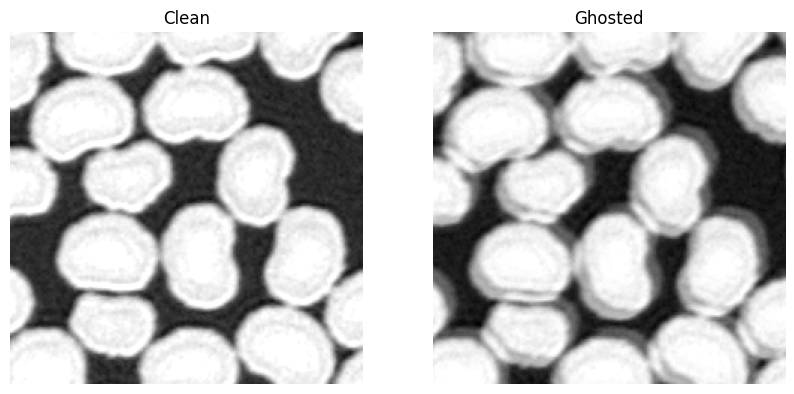

In [122]:
# assume sliced_gray is numpy uint8 image
clean = torch.tensor(sliced_img / 255.0, dtype=torch.float32)

ghost, clean, meta = add_ghost_shadow_safe(clean, max_shift=10)

print(meta)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(clean.squeeze().numpy(), cmap='gray')
ax[0].set_title("Clean")
ax[0].axis("off")

ax[1].imshow(ghost.squeeze().numpy(), cmap='gray')
ax[1].set_title("Ghosted")
ax[1].axis("off")

plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
from torchvision.io import read_image
import torchvision.transforms.v2 as T



def list_images(folder: Path) -> List[Path]:
    exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in exts])


class GhostShadowDataset(Dataset):
    """
    Generates synthetic ghosting:
        ghost = (1-alpha)*clean + alpha*shift(clean, dy, dx)
    plus optional mild blur/noise/contrast jitter.

    Returns:
        ghost:  (1,H,W) float32 in [0,1]
        clean:  (1,H,W) float32 in [0,1]
        meta:   dict with alpha, dy, dx
    """
    def __init__(
        self,
        root: str | Path,
        patch_size: int = 512,
        samples_per_image: int = 4,
        alpha_range: Tuple[float, float] = (0.25, 0.75),
        max_shift: int = 1,                     # your case: 1 px
        allow_diagonal: bool = True,
        add_blur: bool = True,
        blur_sigma_range: Tuple[float, float] = (0.0, 0.8),
        noise_std_range: Tuple[float, float] = (0.0, 0.0),  # in [0,1] units
        contrast_jitter: float = 0.0,            # e.g. 0.05
        brightness_jitter: float = 0.0,          # e.g. 0.02
        seed: Optional[int] = 0,
    ):
        self.root = Path(root)
        self.paths = list_images(self.root)
        if not self.paths:
            raise ValueError(f"No images found in: {self.root}")

        self.patch_size = patch_size
        self.samples_per_image = samples_per_image
        self.alpha_range = alpha_range
        self.max_shift = max_shift
        self.allow_diagonal = allow_diagonal

        self.add_blur = add_blur
        self.blur_sigma_range = blur_sigma_range
        self.noise_std_range = noise_std_range

        self.contrast_jitter = contrast_jitter
        self.brightness_jitter = brightness_jitter

        self.rng = random.Random(seed)

        # light photometric augmentation (applied to clean before ghosting)
        aug = []
        if contrast_jitter > 0 or brightness_jitter > 0:
            aug.append(T.ColorJitter(contrast=contrast_jitter, brightness=brightness_jitter))
        self.photometric = T.Compose(aug) if aug else None

    def __len__(self) -> int:
        return len(self.paths) * self.samples_per_image

    def _choose_shift(self) -> Tuple[int, int]:
        # prefer 1px shifts; allow up to max_shift
        base = [(1,0),(-1,0),(0,1),(0,-1)]
        if self.allow_diagonal:
            base += [(1,1),(1,-1),(-1,1),(-1,-1)]
        dy, dx = self.rng.choice(base)
        s = 1 if self.max_shift <= 1 else self.rng.randint(1, self.max_shift)
        return dy * s, dx * s

    def _random_crop(self, x: torch.Tensor) -> torch.Tensor:
        # x: (1,H,W) in [0,1]
        _, H, W = x.shape
        ps = self.patch_size
        if H < ps or W < ps:
            # pad reflect to reach patch size
            pad_y = max(0, ps - H)
            pad_x = max(0, ps - W)
            x = TF.pad(x, [0, 0, pad_x, pad_y], padding_mode="reflect")
            _, H, W = x.shape

        top = self.rng.randint(0, H - ps)
        left = self.rng.randint(0, W - ps)
        return x[:, top:top+ps, left:left+ps]

    @staticmethod
    def _gaussian_blur(x: torch.Tensor, sigma: float) -> torch.Tensor:
        # x: (1,H,W) float32
        if sigma <= 0:
            return x
        # kernel size heuristic ~ 6*sigma (odd)
        k = max(3, int(round(sigma * 6)) | 1)
        return TF.gaussian_blur(x, kernel_size=[k, k], sigma=[sigma, sigma])

    def __getitem__(self, idx: int):
        img_idx = idx // self.samples_per_image
        path = self.paths[img_idx]

        # read_image -> uint8 (C,H,W), RGB or grayscale
        im = read_image(str(path))  # uint8
        if im.shape[0] == 3:
            im = TF.rgb_to_grayscale(im)
        elif im.shape[0] == 4:
            im = TF.rgb_to_grayscale(im[:3])

        clean = im.float() / 255.0  # (1,H,W) in [0,1]

        # random crop patch
        clean = self._random_crop(clean)

        # optional photometric jitter (expects image-like tensor)
        if self.photometric is not None:
            clean = self.photometric(clean)

        # synth ghosting
        dy, dx = self._choose_shift()
        alpha = self.rng.uniform(*self.alpha_range)

        shifted = torch.roll(clean, shifts=(dy, dx), dims=(-2, -1))

        # optional blur on shifted copy only
        if self.add_blur:
            sigma = self.rng.uniform(*self.blur_sigma_range)
            shifted = self._gaussian_blur(shifted, sigma)

        ghost = (1.0 - alpha) * clean + alpha * shifted

        # optional noise
        nstd = self.rng.uniform(*self.noise_std_range)
        if nstd > 0:
            ghost = ghost + torch.randn_like(ghost) * nstd

        ghost = ghost.clamp(0, 1)

        meta: Dict[str, float] = {"alpha": float(alpha), "dy": float(dy), "dx": float(dx)}
        return ghost, clean, meta
